In [37]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import os
import numpy as np

#os.chdir("src")
import problem
from mesh_io import plot
from utils import L1_error
import analytical
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Test if Reconstruction works

In [ ]:
N_list = [2 ** i for i in range(3, 8)]
L1_0 = []
L1_1 = []

for N in tqdm(N_list):
    mesh0 = problem.run_smooth_sine_1d(Nx=N, Ny=1, max_level=0, reconstruction=0, verbose=False)
    mesh1 = problem.run_smooth_sine_1d(Nx=N, Ny=1, max_level=0, reconstruction=1, verbose=False)

    mesh_exact = analytical.sine_wave_mesh_like(mesh0, t=0.2)

    L1_0.append(np.mean(L1_error(mesh0, mesh_exact, plot=False, verbose=False)))
    L1_1.append(np.mean(L1_error(mesh1, mesh_exact, plot=False, verbose=False)))

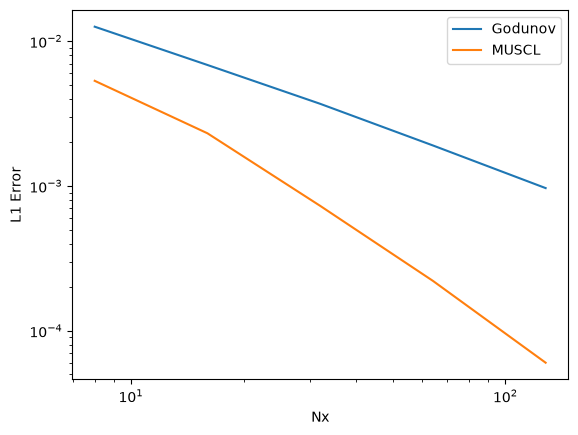

In [4]:
plt.loglog(N_list, L1_0, label='Godunov')
plt.loglog(N_list, L1_1, label='MUSCL')
plt.xlabel("Nx")
plt.ylabel("L1 Error")
plt.legend()

# Test AMR Method

In [2]:
N_list = [2 ** i for i in range(3, 8)]
L1_0 = []
L1_1 = []

for N in tqdm(N_list):
    N = int(N)
    mesh0 = problem.run_sod_1d(Nx=N, Ny=1, max_level=3, mode='in_step', verbose=False,)
    mesh1 = problem.run_sod_1d(Nx=N, Ny=1, max_level=3, mode='between', verbose=False,)

    mesh_exact = analytical.exact_mesh_like(mesh0, t=0.2)

    L1_0.append(np.mean(L1_error(mesh0, mesh_exact, plot=False, verbose=False)))
    L1_1.append(np.mean(L1_error(mesh1, mesh_exact, plot=False, verbose=False)))

100%|██████████| 5/5 [04:00<00:00, 48.08s/it]


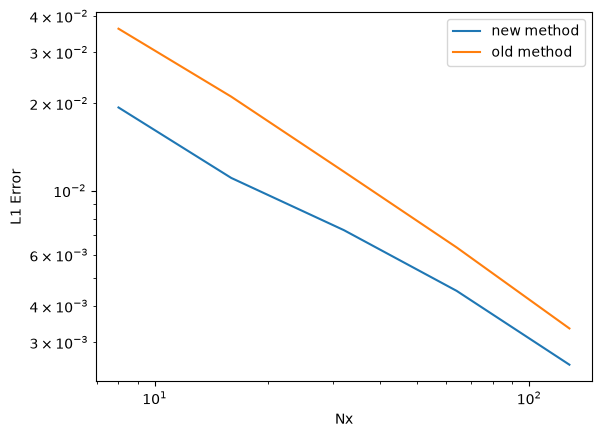

In [3]:
plt.loglog(N_list, L1_0, label='new method')
plt.loglog(N_list, L1_1, label='old method')
plt.xlabel("Nx")
plt.ylabel("L1 Error")
plt.legend()

# Test CFL

In [6]:
np.vstack([L1_0, L1_1])

array([[0.01934455, 0.01105498, 0.0073    , 0.00450771, 0.00250832],
       [0.03615986, 0.02108069, 0.01161515, 0.00636489, 0.0033453 ]])

In [10]:
cfl_list = np.linspace(0, 1, 5)
err = {}
for cfl in cfl_list[1:]:
    N_list = [2 ** i for i in range(3, 7)]
    L1_0 = []
    L1_1 = []

    for N in tqdm(N_list):
        N = int(N)
        mesh0 = problem.run_sod_1d(Nx=N, Ny=1, max_level=3, mode='in_step', verbose=False, cfl=cfl)
        mesh1 = problem.run_sod_1d(Nx=N, Ny=1, max_level=3, mode='between', verbose=False, cfl=cfl)

        mesh_exact = analytical.exact_mesh_like(mesh0, t=0.2)

        L1_0.append(np.mean(L1_error(mesh0, mesh_exact, plot=False, verbose=False)))
        L1_1.append(np.mean(L1_error(mesh1, mesh_exact, plot=False, verbose=False)))

    err[cfl] = np.vstack([L1_0, L1_1])

100%|██████████| 4/4 [00:41<00:00, 10.45s/it]


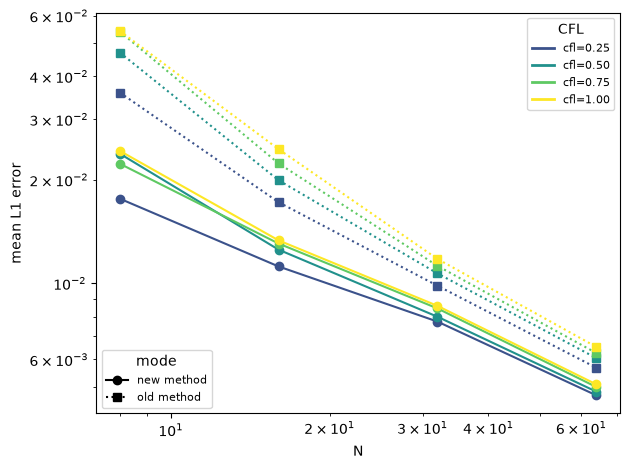

In [14]:
import matplotlib.lines as mlines

cmap = plt.get_cmap('viridis')
colors = {cfl: cmap(i / max(len(cfl_list) - 1, 1)) for i, cfl in enumerate(cfl_list)}

fig, ax = plt.subplots()

for cfl in cfl_list[1:]:
    L1_0, L1_1 = err[cfl]          # L1_0 = in_step, L1_1 = between
    c = colors[cfl]
    ax.loglog(N_list, L1_0, '-',  color=c, marker='o')   # in_step  -> solid
    ax.loglog(N_list, L1_1, ':',  color=c, marker='s')   # between  -> dotted

ax.set_xlabel('N')
ax.set_ylabel('mean L1 error')

cfl_handles = [mlines.Line2D([], [], color=colors[cfl], lw=2, label=f'cfl={cfl:.2f}')
               for cfl in cfl_list[1:]]
leg1 = ax.legend(handles=cfl_handles, title='CFL', loc='upper right', fontsize=8)
ax.add_artist(leg1)

mode_handles = [
    mlines.Line2D([], [], color='k', linestyle='-',  marker='o', label='new method'),
    mlines.Line2D([], [], color='k', linestyle=':',  marker='s', label='old method'),
]
ax.legend(handles=mode_handles, title='mode', loc='lower left', fontsize=8)

plt.tight_layout()

# Test 2D

## 1. Blast

step   20  t=0.0274  dt=8.54e-04  get_active_cells= 2488
step   40  t=0.0444  dt=8.40e-04  get_active_cells= 3052
step   60  t=0.0612  dt=8.43e-04  get_active_cells= 3811
step   80  t=0.0782  dt=8.60e-04  get_active_cells= 4300
step  100  t=0.0957  dt=8.85e-04  get_active_cells= 5041
step  120  t=0.1136  dt=9.04e-04  get_active_cells= 5395
step  140  t=0.1319  dt=9.29e-04  get_active_cells= 5692
step  160  t=0.1500  dt=2.72e-04  get_active_cells= 5926
done: 160 steps, t=0.1500, 


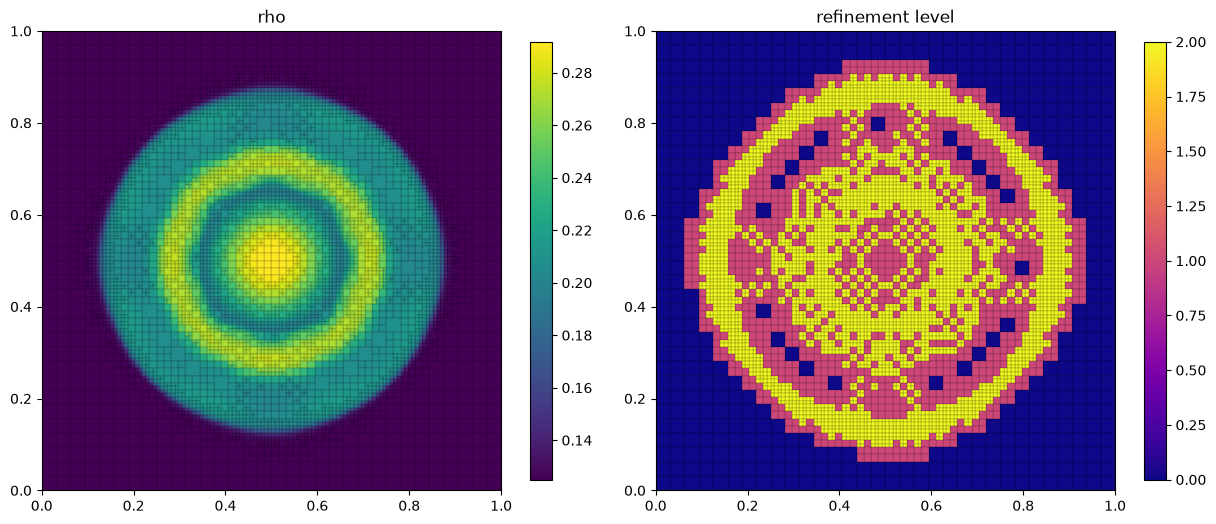

In [62]:
mesh_old = problem.run_blast(Nx=32, max_level=2, init=True, mode='between')
plot(mesh_old)

step   20  t=0.0200  dt=8.30e-04  get_active_cells= 2476
step   40  t=0.0363  dt=8.16e-04  get_active_cells= 3016
step   60  t=0.0527  dt=8.27e-04  get_active_cells= 3466
step   80  t=0.0695  dt=8.48e-04  get_active_cells= 4024
step  100  t=0.0867  dt=8.74e-04  get_active_cells= 4522
step  120  t=0.1044  dt=8.93e-04  get_active_cells= 4918
step  140  t=0.1223  dt=9.05e-04  get_active_cells= 5458
step  160  t=0.1406  dt=9.19e-04  get_active_cells= 5806
done: 171 steps, t=0.1500, 


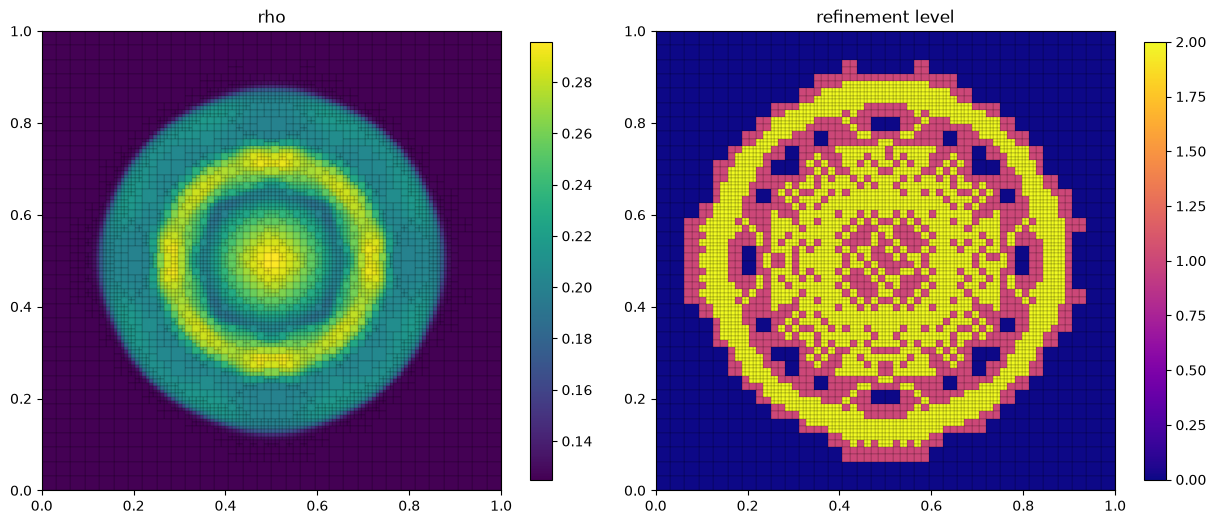

In [63]:
mesh_new = problem.run_blast(Nx=32, max_level=2, init=True, mode='in_step')
plot(mesh_new)

step   20  t=0.0368  dt=1.69e-03  get_active_cells= 4096
step   40  t=0.0709  dt=1.72e-03  get_active_cells= 4096
step   60  t=0.1061  dt=1.80e-03  get_active_cells= 4096
step   80  t=0.1429  dt=1.86e-03  get_active_cells= 4096
done: 84 steps, t=0.1500, 


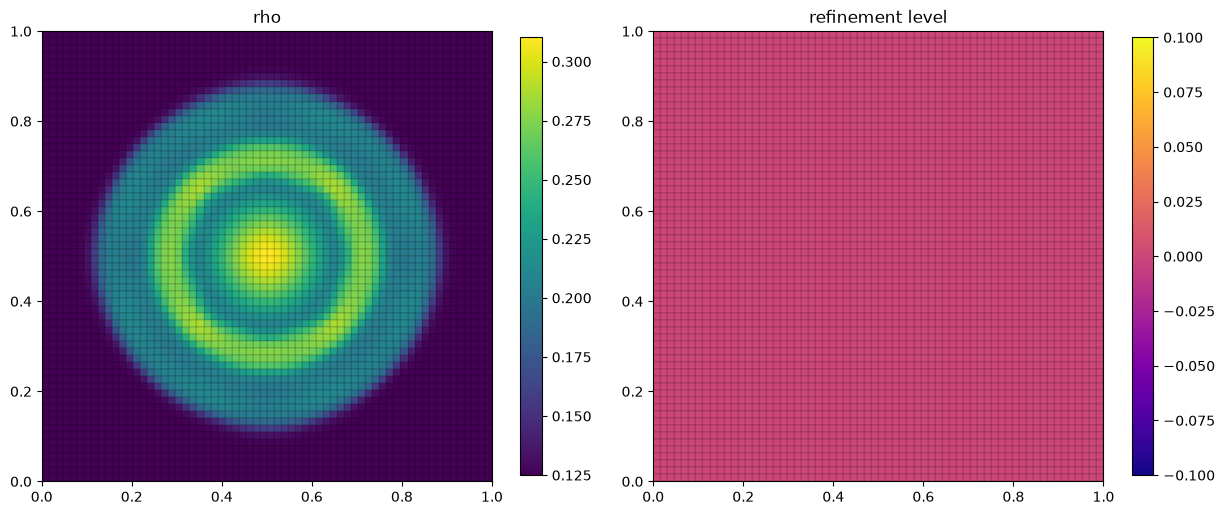

In [64]:
mesh_uniform = problem.run_blast(Nx=64, max_level=0, init=True, mode='between')
plot(mesh_uniform)

In [68]:
from utils import grad_init
mesh_old = grad_init(mesh_old)

In [ ]:
mesh_old = grad_init(mesh_old)

Mean L1 Error: 7.320e-03
L1 error for rho: 3.417e-03, vx: 1.135e-02, vy: 1.135e-02, P: 3.158e-03


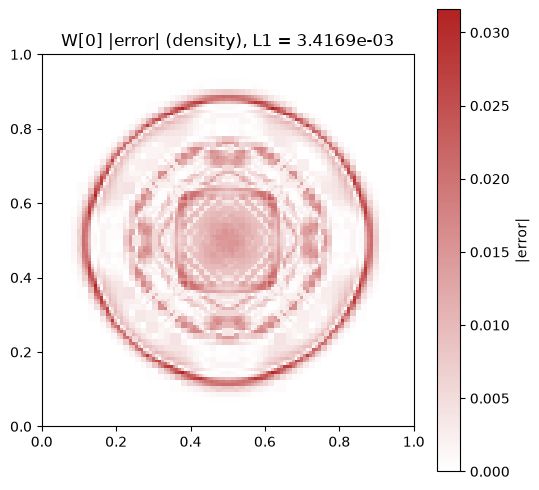

array([0.00341692, 0.01135288, 0.01135288, 0.00315831])

In [66]:
L1_error(mesh_new, mesh_uniform)

In [67]:
L1_error(mesh_new, mesh_old)

AssertionError: 